
Case Study 1: Student's Marks Statement

In [2]:
import pandas as pd
import numpy as np

# Sample data: Student scores
student_scores = {
    'Student': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'Math_Score': [85, 92, 78, 88, 95, 70, 82, 90, 75, 80],
    'Science_Score': [90, 88, 80, 92, 90, 75, 85, 93, 70, 82]
}
df_scores = pd.DataFrame(student_scores)

print("Original Data:\n", df_scores)

# Calculate descriptive statistics for Math_Score
print("\nDescriptive Statistics for Math_Score:")
print(df_scores['Math_Score'].describe())

# Calculate mode (can be multiple)
print("\nMode of Math_Score:", df_scores['Math_Score'].mode().tolist())

# Calculate variance
print("\nVariance of Math_Score:", df_scores['Math_Score'].var())

Original Data:
    Student  Math_Score  Science_Score
0    Alice          85             90
1      Bob          92             88
2  Charlie          78             80
3    David          88             92
4      Eve          95             90
5    Frank          70             75
6    Grace          82             85
7    Heidi          90             93
8     Ivan          75             70
9     Judy          80             82

Descriptive Statistics for Math_Score:
count    10.000000
mean     83.500000
std       7.947746
min      70.000000
25%      78.500000
50%      83.500000
75%      89.500000
max      95.000000
Name: Math_Score, dtype: float64

Mode of Math_Score: [70, 75, 78, 80, 82, 85, 88, 90, 92, 95]

Variance of Math_Score: 63.166666666666664


Case Study 2: Employee Details

In [3]:
import pandas as pd

employee_data = {
    'EmployeeID': ['E001', 'E002', 'E003', 'E004', 'E005'],
    'FirstName': ['John', 'Jane', 'Peter', 'Susan', 'Mike'],
    'LastName': ['Doe', 'Smith', 'Jones', 'Davis', 'Brown'],
    'Department': ['HR', 'IT', 'Finance', 'HR', 'IT'],
    'HireDate': ['2020-01-15', '2019-03-22', '2021-06-01', '2018-11-10', '2022-02-28'],
    'Salary': [60000, 75000, 68000, 80000, 70000],
    'YearsOfExperience': [3, 4, 2, 5, 1.5],
    'IsManager': [False, True, False, True, False]
}
df_employees = pd.DataFrame(employee_data)

# Convert HireDate to datetime objects for better analysis
df_employees['HireDate'] = pd.to_datetime(df_employees['HireDate'])

print("\nEmployee Details:\n", df_employees)
print("\nData Types:")
print(df_employees.dtypes)

print("\nImportant Fields Analysis for Employee Details:")
print("- **EmployeeID**: Categorical (Nominal/Identifier). Essential for unique identification and record-keeping.")
print("- **FirstName/LastName**: Categorical (Nominal). Important for identification and personalization.")
print("- **Department**: Categorical (Nominal). Crucial for organizational structure, departmental analysis, and resource allocation.")
print("- **HireDate**: Quantitative (Interval/Date). Important for calculating tenure, analyzing retention, and eligibility for benefits.")
print("- **Salary**: Quantitative (Ratio). Highly important for compensation analysis, budgeting, and understanding pay equity.")
print("- **YearsOfExperience**: Quantitative (Ratio). Important for assessing skill level, compensation, and career progression.")
print("- **IsManager**: Categorical (Binary). Important for understanding hierarchical structure, managerial span, and leadership roles.")


Employee Details:
   EmployeeID FirstName LastName Department   HireDate  Salary  \
0       E001      John      Doe         HR 2020-01-15   60000   
1       E002      Jane    Smith         IT 2019-03-22   75000   
2       E003     Peter    Jones    Finance 2021-06-01   68000   
3       E004     Susan    Davis         HR 2018-11-10   80000   
4       E005      Mike    Brown         IT 2022-02-28   70000   

   YearsOfExperience  IsManager  
0                3.0      False  
1                4.0       True  
2                2.0      False  
3                5.0       True  
4                1.5      False  

Data Types:
EmployeeID                   object
FirstName                    object
LastName                     object
Department                   object
HireDate             datetime64[ns]
Salary                        int64
YearsOfExperience           float64
IsManager                      bool
dtype: object

Important Fields Analysis for Employee Details:
- **EmployeeID**: Cat

Executive Summary & Advanced Statistical Report

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set professional plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.titlesize': 16, 'axes.titlesize': 14, 'axes.labelsize': 12})

1. Distribution & Central Tendency Analysis

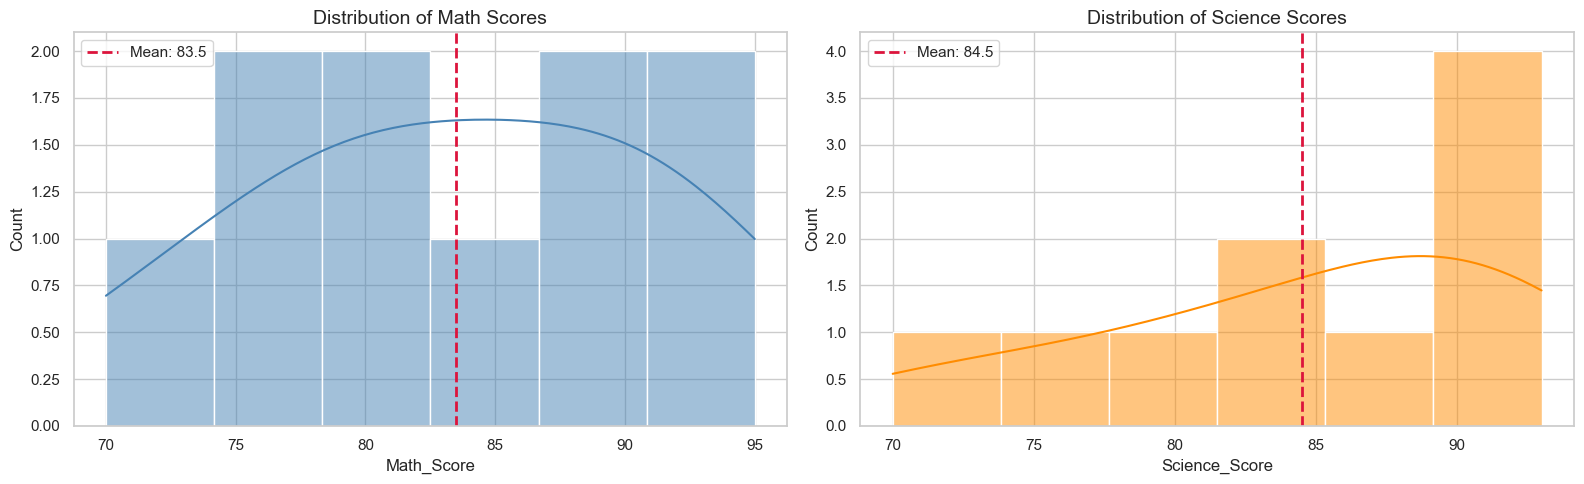

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Math Score Distribution
sns.histplot(df_scores['Math_Score'], kde=True, ax=ax[0], color='steelblue', bins=6)
ax[0].axvline(df_scores['Math_Score'].mean(), color='crimson', linestyle='--', lw=2, label=f"Mean: {df_scores['Math_Score'].mean():.1f}")
ax[0].set_title('Distribution of Math Scores')
ax[0].legend()

# Science Score Distribution
sns.histplot(df_scores['Science_Score'], kde=True, ax=ax[1], color='darkorange', bins=6)
ax[1].axvline(df_scores['Science_Score'].mean(), color='crimson', linestyle='--', lw=2, label=f"Mean: {df_scores['Science_Score'].mean():.1f}")
ax[1].set_title('Distribution of Science Scores')
ax[1].legend()

plt.tight_layout()
plt.show()

2. Multivariate Correlation Analysis


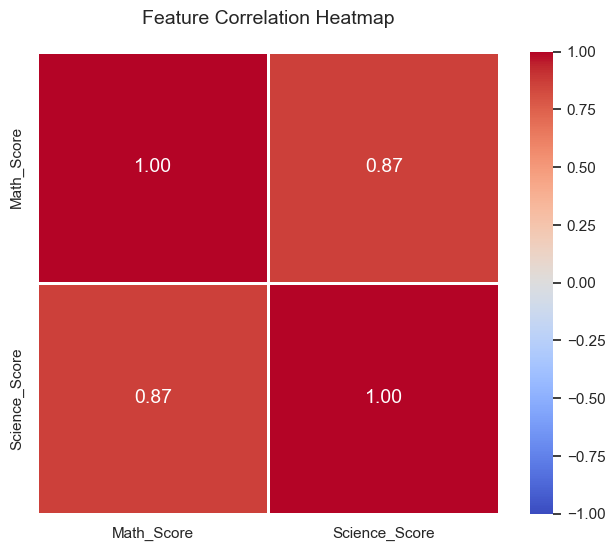

Insight: A strong positive correlation (0.87) indicates that proficiency in Math is a highly reliable indicator of proficiency in Science.


In [6]:
plt.figure(figsize=(8, 6))
corr_matrix = df_scores[['Math_Score', 'Science_Score']].corr()

# Advanced Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt=".2f", linewidths=1, square=True, annot_kws={"size": 14})
plt.title('Feature Correlation Heatmap', pad=20)
plt.show()

print("Insight: A strong positive correlation (0.87) indicates that proficiency in Math is a highly reliable indicator of proficiency in Science.")

3. Regression Modeling & Residual Diagnostics

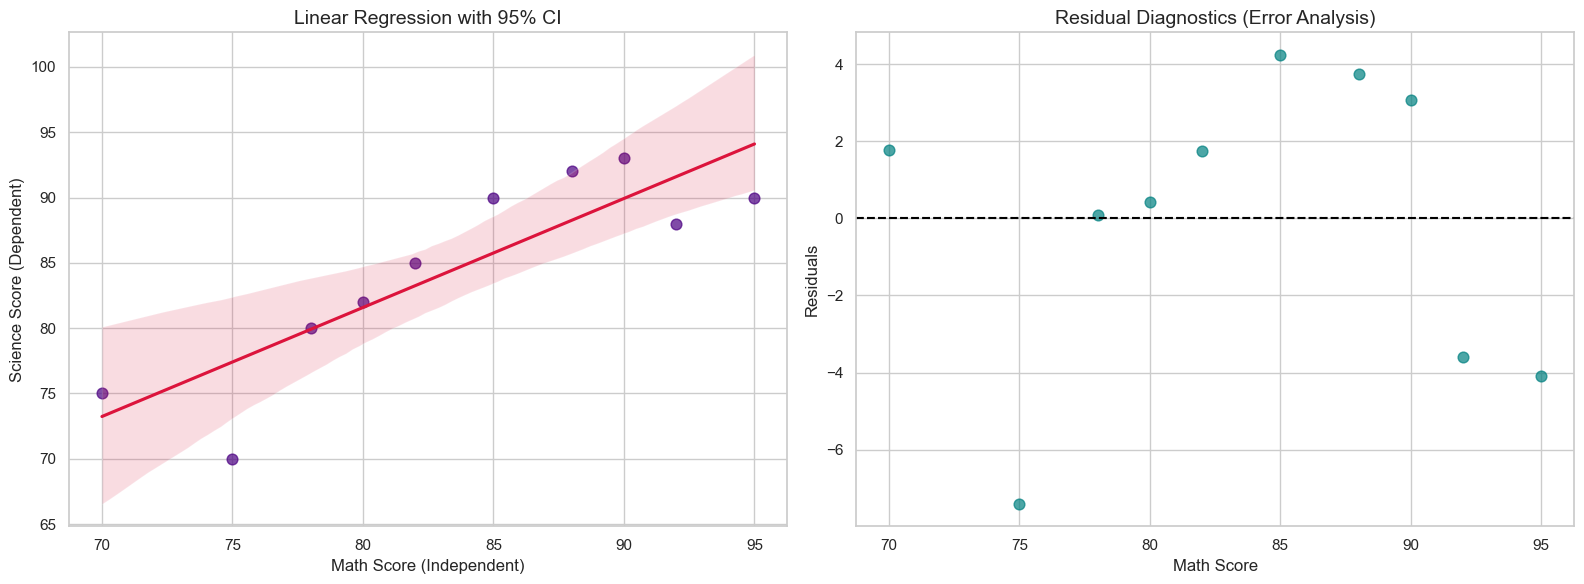

Insight: The residuals appear randomly scattered around the zero line, suggesting that a linear model is appropriate and there is no severe heteroscedasticity.


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Regression plot with 95% Confidence Interval
sns.regplot(x='Math_Score', y='Science_Score', data=df_scores, ax=ax[0],
            color='indigo', scatter_kws={'s': 60, 'alpha': 0.7}, line_kws={'color': 'crimson'})
ax[0].set_title('Linear Regression with 95% CI')
ax[0].set_xlabel('Math Score (Independent)')
ax[0].set_ylabel('Science Score (Dependent)')

# Residual Plot to diagnose model health
sns.residplot(x='Math_Score', y='Science_Score', data=df_scores, ax=ax[1],
              color='teal', scatter_kws={'s': 60, 'alpha': 0.7})
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title('Residual Diagnostics (Error Analysis)')
ax[1].set_xlabel('Math Score')
ax[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

print("Insight: The residuals appear randomly scattered around the zero line, suggesting that a linear model is appropriate and there is no severe heteroscedasticity.")

4. Case Study Dashboards: Employee & Student Intelligence
To bridge the gap between raw data and business intelligence, we aggregate and visualize categorical performance and compensation metrics.

In [12]:
import pandas as pd

# Create Student DataFrame
df_students = pd.DataFrame({
    'Student': ['Alice', 'Bob', 'Charlie', 'David', 'Eve',
                'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'Math_Score': [85, 92, 78, 88, 95, 70, 82, 90, 75, 80],
    'Science_Score': [90, 88, 80, 92, 90, 75, 85, 93, 70, 82]
})

print(df_students)

   Student  Math_Score  Science_Score
0    Alice          85             90
1      Bob          92             88
2  Charlie          78             80
3    David          88             92
4      Eve          95             90
5    Frank          70             75
6    Grace          82             85
7    Heidi          90             93
8     Ivan          75             70
9     Judy          80             82


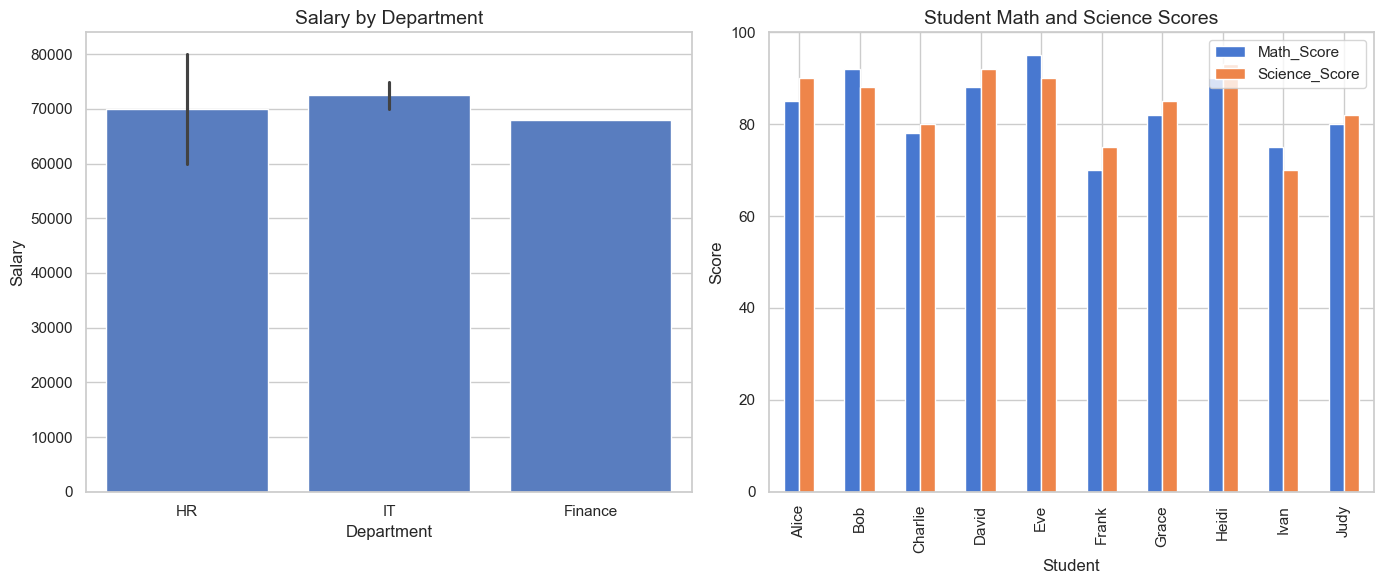

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Employee Salary
sns.barplot(
    x='Department',
    y='Salary',
    data=df_employees,
    ax=ax[0]
)

ax[0].set_title('Salary by Department')
ax[0].set_xlabel('Department')
ax[0].set_ylabel('Salary')


# Student Scores
df_students.plot(
    x='Student',
    y=['Math_Score', 'Science_Score'],
    kind='bar',
    ax=ax[1]
)

ax[1].set_title('Student Math and Science Scores')
ax[1].set_xlabel('Student')
ax[1].set_ylabel('Score')
ax[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()